# Experiment — CNN-GRU with Optuna search

Same architecture as the baseline, with an Optuna study over hidden size, number of layers, dropout, learning rate, weight decay and label smoothing.

**Best validation weighted-F1: 0.9262** — no improvement over the hand-tuned baseline, so the search space was later moved to the windowing parameters instead.

---


## Google Drive Connection


In [ ]:
# --- Paths ---------------------------------------------------------------
# Originally executed on Google Colab with the dataset on Google Drive.
# DATA_DIR must contain: pirate_pain_train.csv, pirate_pain_train_labels.csv,
# pirate_pain_test.csv, sample_submission.csv  (see data/README.md)
import os

DATA_DIR = os.environ.get("PIRATE_DATA_DIR", "data")
os.makedirs("models", exist_ok=True)
os.makedirs("artifacts", exist_ok=True)


## Libraries Import


In [ ]:
# Set seed for reproducibility
SEED = 42

# Import necessary libraries
import os

# Set environment variables before importing modules
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['MPLCONFIGDIR'] = os.getcwd() + '/configs/'

# Suppress warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=Warning)

# Import necessary modules
import logging
import random
import numpy as np

# Set seeds for random number generators in NumPy and Python
np.random.seed(SEED)
random.seed(SEED)

# Import PyTorch
import torch
torch.manual_seed(SEED)
from torch import nn
# from torchsummary import summary
from torch.utils.tensorboard import SummaryWriter
from torch.utils.data import TensorDataset, DataLoader
logs_dir = "tensorboard"
%load_ext tensorboard
!mkdir -p models

if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
else:
    device = torch.device("cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

# Import other libraries
import copy
import shutil
from itertools import product
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configure plot display settings
sns.set(font_scale=1.4)
sns.set_style('white')
plt.rc('font', size=14)
%matplotlib inline
import optuna
from optuna.trial import Trial
from optuna.samplers import TPESampler

from sklearn.model_selection import StratifiedKFold

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard
PyTorch version: 2.8.0+cu126
Device: cuda


## Exploration and Data Analysis


In [ ]:
X_train = pd.read_csv('../Dataset/pirate_pain_train.csv')
y_train = pd.read_csv('../Dataset/pirate_pain_train_labels.csv')

X_test = pd.read_csv('../Dataset/pirate_pain_test.csv')

In [ ]:
# Check for and drop columns with only one unique value
cols_to_drop = []
for col in X_train.columns:
  if X_train[col].nunique() == 1:
    print(f"Column '{col}' has only one unique value")
    cols_to_drop.append(col)

X_train = X_train.drop(columns=cols_to_drop)

Column 'joint_30' has only one unique value


In [ ]:
# Define a mapping for string representations of strings to integers
legs_mapping = {
    'two': 2,
    'one+peg_leg': 1
}

hands_mapping = {
    'two': 2,
    'one+hook_hand': 1
}

eyes_mapping = {
    'two': 2,
    'one+eye_patch': 1
}

# Convert 'n_legs', 'n_hands', and 'n_eyes' to integers using the mapping
X_train['n_legs'] = X_train['n_legs'].map(legs_mapping)
X_train['n_hands'] = X_train['n_hands'].map(hands_mapping)
X_train['n_eyes'] = X_train['n_eyes'].map(eyes_mapping)

X_test['n_legs'] = X_test['n_legs'].map(legs_mapping)
X_test['n_hands'] = X_test['n_hands'].map(hands_mapping)
X_test['n_eyes'] = X_test['n_eyes'].map(eyes_mapping)

In [ ]:
# Convert 'joint_*' columns to float32 data type to use less memory
for col in X_train.columns:
  if 'joint' in col:
    X_train[col] = X_train[col].astype(np.float32)

for col in X_test.columns:
  if 'joint' in col:
    X_test[col] = X_test[col].astype(np.float32)

In [ ]:
# Define a mapping of status names to integer labels
label_mapping = {
    'no_pain': 0,
    'low_pain': 1,
    'high_pain': 2
}

# Map status names to integers in the labels set
y_train['label'] = y_train['label'].map(label_mapping)

In [ ]:
# Merge features + labels
train_df = X_train.merge(y_train, on="sample_index")
test_df = X_test.copy()

In [ ]:
# Define the columns to be normalised
num_joints = 29
scale_columns = [f'joint_{i:02d}' for i in range(num_joints+1)]

def normalize_minmax(df_train, df_val, df_test):
    mins = df_train[scale_columns].min()
    maxs = df_train[scale_columns].max()
    for col in scale_columns:
        for df in [df_train, df_val, df_test]:
            df[col] = (df[col] - mins[col]) / (maxs[col] - mins[col])
    return df_train, df_val, df_test

In [ ]:
# Define the window size
WINDOW_SIZE = 200

# Define the stride for overlapping windows (so it defines the lenght of the sequence)
STRIDE = 50

In [ ]:
# @title
# Define a function to build sequences from the dataset
def build_sequences(df, window=200, stride=200, is_test=False):
    # Sanity check to ensure the window is divisible by the stride
    assert window % stride == 0

    # Initialise lists to store sequences and their corresponding labels
    dataset = []
    labels = []

    num_surveys = 4
    num_joints = 29
    rel_col = [f'pain_survey_{i+1}' for i in range(num_surveys)] + [f'joint_{i:02d}' for i in range(num_joints+1)]

    # Iterate over unique IDs in the DataFrame
    for id in df['sample_index'].unique():
        # Extract sensor data for the current ID
        temp = df[df['sample_index'] == id][rel_col].values

        # Retrieve the activity label for the current ID only if not the test set
        if not is_test:
            label = y_train[y_train['sample_index'] == id]['label'].values[0]

        # Calculate padding length to ensure full windows (to avoid the last sequence to be shorter than the others)
        padding_len = window - len(temp) % window

        # Create zero padding and concatenate with the data
        padding = np.zeros((padding_len, len(rel_col)), dtype='float32')
        temp = np.concatenate((temp, padding))

        # Build feature windows and associate them with labels
        idx = 0
        while idx + window <= len(temp):
            dataset.append(temp[idx:idx + window])
            if not is_test:
              labels.append(label)
            idx += stride


    # Convert lists to numpy arrays for further processing
    dataset = np.array(dataset)
    labels = np.array(labels)

    if is_test:
        return dataset
    else:
        return dataset, labels

In [ ]:
# @title
def make_loader(ds, batch_size, shuffle, drop_last):
    # Determine optimal number of worker processes for data loading
    cpu_cores = os.cpu_count() or 2
    num_workers = max(2, min(4, cpu_cores))

    # Get labels from the dataset for weighted sampling
    if hasattr(ds, 'tensors'):
        # For TensorDataset, labels are the second tensor
        dataset_labels = ds.tensors[1].numpy() if len(ds.tensors) > 1 else None
    elif hasattr(ds, 'labels'):
        # For custom datasets with a 'labels' attribute
        dataset_labels = ds.labels
    else:
        dataset_labels = None

    sampler = None
    if dataset_labels is not None and shuffle:
        class_counts = np.bincount(dataset_labels)
        # Avoid division by zero
        class_weights = 1.0 / (class_counts + 1e-9)
        sample_weights = class_weights[dataset_labels]
        from torch.utils.data import WeightedRandomSampler
        sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)
        shuffle = False # Shuffle is handled by the sampler

    # Create DataLoader with performance optimizations
    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=num_workers,
        pin_memory=True,  # Faster GPU transfer
        pin_memory_device="cuda" if torch.cuda.is_available() else "",
        prefetch_factor=4,  # Load 4 batches ahead
        sampler=sampler # Use the sampler if created
    )

## Model Building


In [ ]:
input_shape = (200, 34)
num_classes = 3

In [ ]:
# @title
def recurrent_summary(model, input_size):
    """Custom summary function that emulates torchinfo's output while correctly
    counting parameters for RNN/GRU/LSTM layers.

    This function is designed for models whose direct children are
    nn.Linear, nn.RNN, nn.GRU, or nn.LSTM layers.

    Args:
        model (nn.Module): The model to analyze.
        input_size (tuple): Shape of the input tensor (e.g., (seq_len, features)).
    """

    # Dictionary to store output shapes captured by forward hooks
    output_shapes = {}
    # List to track hook handles for later removal
    hooks = []

    def get_hook(name):
        """Factory function to create a forward hook for a specific module."""
        def hook(module, input, output):
            # Handle RNN layer outputs (returns a tuple)
            if isinstance(output, tuple):
                # output[0]: all hidden states with shape (batch, seq_len, hidden*directions)
                shape1 = list(output[0].shape)
                shape1[0] = -1  # Replace batch dimension with -1

                # output[1]: final hidden state h_n (or tuple (h_n, c_n) for LSTM)
                if isinstance(output[1], tuple):  # LSTM case: (h_n, c_n)
                    shape2 = list(output[1][0].shape)  # Extract h_n only
                else:  # RNN/GRU case: h_n only
                    shape2 = list(output[1].shape)

                # Replace batch dimension (middle position) with -1
                shape2[1] = -1

                output_shapes[name] = f"[{shape1}, {shape2}]"

            # Handle standard layer outputs (e.g., Linear)
            else:
                shape = list(output.shape)
                shape[0] = -1  # Replace batch dimension with -1
                output_shapes[name] = f"{shape}"
        return hook

    # 1. Determine the device where model parameters reside
    try:
        device = next(model.parameters()).device
    except StopIteration:
        device = torch.device("cpu")  # Fallback for models without parameters

    # 2. Create a dummy input tensor with batch_size=1
    dummy_input = torch.randn(1, *input_size).to(device)

    # 3. Register forward hooks on target layers
    # Iterate through direct children of the model (e.g., self.rnn, self.classifier)
    for name, module in model.named_children():
        if isinstance(module, (nn.Linear, nn.RNN, nn.GRU, nn.LSTM)):
            # Register the hook and store its handle for cleanup
            hook_handle = module.register_forward_hook(get_hook(name))
            hooks.append(hook_handle)

    # 4. Execute a dummy forward pass in evaluation mode
    model.eval()
    with torch.no_grad():
        try:
            model(dummy_input)
        except Exception as e:
            print(f"Error during dummy forward pass: {e}")
            # Clean up hooks even if an error occurs
            for h in hooks:
                h.remove()
            return

    # 5. Remove all registered hooks
    for h in hooks:
        h.remove()

    # --- 6. Print the summary table ---

    print("-" * 79)
    # Column headers
    print(f"{'Layer (type)':<25} {'Output Shape':<28} {'Param #':<18}")
    print("=" * 79)

    total_params = 0
    total_trainable_params = 0

    # Iterate through modules again to collect and display parameter information
    for name, module in model.named_children():
        if name in output_shapes:
            # Count total and trainable parameters for this module
            module_params = sum(p.numel() for p in module.parameters())
            trainable_params = sum(p.numel() for p in module.parameters() if p.requires_grad)

            total_params += module_params
            total_trainable_params += trainable_params

            # Format strings for display
            layer_name = f"{name} ({type(module).__name__})"
            output_shape_str = str(output_shapes[name])
            params_str = f"{trainable_params:,}"

            print(f"{layer_name:<25} {output_shape_str:<28} {params_str:<15}")

    print("=" * 79)
    print(f"Total params: {total_params:,}")
    print(f"Trainable params: {total_trainable_params:,}")
    print(f"Non-trainable params: {total_params - total_trainable_params:,}")
    print("-" * 79)

In [ ]:
# @title
import torch
from torch import nn

class CNN_GRU_Classifier(nn.Module):
    """Hybrid CNN + GRU classifier for multivariate time series.
    Captures local temporal patterns via CNN and global dependencies via GRU.
    """

    def __init__(
        self,
        input_size: int,
        num_classes: int,
        hidden_size: int = 128,
        num_layers: int = 2,
        dropout_rate: float = 0.3,
        bidirectional: bool = False,
        use_attention: bool = True,
    ):
        super().__init__()

        self.bidirectional = bidirectional
        self.use_attention = use_attention
        gru_input_size = 128

        # --- CNN feature extractor ---
        self.cnn = nn.Sequential(
            nn.Conv1d(input_size, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Conv1d(64, gru_input_size, kernel_size=3, padding=1),
            nn.BatchNorm1d(gru_input_size),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
        )

        # --- GRU encoder ---
        self.gru = nn.GRU(
            input_size=gru_input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout_rate if num_layers > 1 else 0,
            bidirectional=bidirectional,
        )

        # --- Optional Attention Pooling ---
        if use_attention:
            self.attention = nn.Sequential(
                nn.Linear(hidden_size * (2 if bidirectional else 1), 64),
                nn.Tanh(),
                nn.Linear(64, 1, bias=False)
            )

        # --- Final classifier ---
        fc_input = hidden_size * (2 if bidirectional else 1)
        self.fc = nn.Sequential(
            nn.Linear(fc_input, 128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        """
        x shape: (batch_size, seq_len, input_size)
        """
        # CNN expects (batch, features, seq_len)
        x = x.permute(0, 2, 1)
        x = self.cnn(x)
        x = x.permute(0, 2, 1)

        # GRU encoding
        out, _ = self.gru(x)

        if self.use_attention:
            # Attention weights
            attn_weights = torch.softmax(self.attention(out), dim=1)
            x = torch.sum(out * attn_weights, dim=1)
        else:
            # Mean pooling
            x = out.mean(dim=1)

        return self.fc(x)


# Create model and display architecture with parameter count
rnn_model = CNN_GRU_Classifier(
    input_size=input_shape[-1],
    num_classes=num_classes,
    hidden_size=128,
    num_layers=2,
    dropout_rate=0.,
    bidirectional=False,
    use_attention=True  # or False for plain mean pooling
).to(device)
recurrent_summary(rnn_model, input_size=input_shape)

-------------------------------------------------------------------------------
Layer (type)              Output Shape                 Param #
gru (GRU)                 [[-1, 200, 128], [2, -1, 128]] 198,144
Total params: 198,144
Trainable params: 198,144
Non-trainable params: 0
-------------------------------------------------------------------------------


## Network and Training Hyperparameters


## Model Training


In [ ]:
# @title
# Initialize best model tracking variables
best_model = None
best_performance = float('-inf')

In [ ]:
# @title
def train_one_epoch(model, train_loader, criterion, optimizer, scaler, device, l1_lambda=0, l2_lambda=0):
    """Perform one complete training epoch through the entire training dataset.

    Args:
        model (nn.Module): The neural network model to train
        train_loader (DataLoader): PyTorch DataLoader containing training data batches
        criterion (nn.Module): Loss function (e.g., CrossEntropyLoss, MSELoss)
        optimizer (torch.optim): Optimization algorithm (e.g., Adam, SGD)
        scaler (GradScaler): PyTorch's gradient scaler for mixed precision training
        device (torch.device): Computing device ('cuda' for GPU, 'cpu' for CPU)
        l1_lambda (float): Lambda for L1 regularization
        l2_lambda (float): Lambda for L2 regularization

    Returns:
        tuple: (average_loss, f1 score) - Training loss and f1 score for this epoch
    """
    model.train()  # Set model to training mode

    running_loss = 0.0
    all_predictions = []
    all_targets = []

    # Iterate through training batches
    for batch_idx, (inputs, targets) in enumerate(train_loader):
        # Move data to device (GPU/CPU) and convert to float32
        inputs, targets = inputs.to(device).float(), targets.to(device)

        # Clear gradients from previous step
        optimizer.zero_grad(set_to_none=True)

        # Forward pass with mixed precision (if CUDA available)
        with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
            logits = model(inputs)
            loss = criterion(logits, targets)

            # Add L1 and L2 regularization
            l1_norm = sum(p.abs().sum() for p in model.parameters())
            l2_norm = sum(p.pow(2).sum() for p in model.parameters())
            loss = loss + l1_lambda * l1_norm + l2_lambda * l2_norm


        # Backward pass with gradient scaling
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        # Accumulate metrics
        running_loss += loss.item() * inputs.size(0)
        predictions = logits.argmax(dim=1)
        all_predictions.append(predictions.cpu().numpy())
        all_targets.append(targets.cpu().numpy())

    # Calculate epoch metrics
    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_f1 = f1_score(
        np.concatenate(all_targets),
        np.concatenate(all_predictions),
        average='weighted'
    )

    return epoch_loss, epoch_f1

In [ ]:
# @title
def validate_one_epoch(model, val_loader, criterion, device):
    """Perform one complete validation epoch through the entire validation dataset.

    Args:
        model (nn.Module): The neural network model to evaluate (must be in eval mode)
        val_loader (DataLoader): PyTorch DataLoader containing validation data batches
        criterion (nn.Module): Loss function used to calculate validation loss
        device (torch.device): Computing device ('cuda' for GPU, 'cpu' for CPU)

    Returns:
        tuple: (average_loss, accuracy) - Validation loss and accuracy for this epoch

    Note:
        This function automatically sets the model to evaluation mode and disables
        gradient computation for efficiency during validation.
    """
    model.eval()  # Set model to evaluation mode

    running_loss = 0.0
    all_predictions = []
    all_targets = []

    # Disable gradient computation for validation
    with torch.no_grad():
        for inputs, targets in val_loader:
            # Move data to device
            inputs, targets = inputs.to(device).float(), targets.to(device)

            # Forward pass with mixed precision (if CUDA available)
            with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
                logits = model(inputs)
                loss = criterion(logits, targets)

            # Accumulate metrics
            running_loss += loss.item() * inputs.size(0)
            predictions = logits.argmax(dim=1)
            all_predictions.append(predictions.cpu().numpy())
            all_targets.append(targets.cpu().numpy())

    # Calculate epoch metrics
    epoch_loss = running_loss / len(val_loader.dataset)
    epoch_accuracy = f1_score(
        np.concatenate(all_targets),
        np.concatenate(all_predictions),
        average='weighted'
    )

    return epoch_loss, epoch_accuracy

In [ ]:
# @title
def fit(model, train_loader, val_loader, epochs, criterion, optimizer, scaler, device,
        l1_lambda=0, l2_lambda=0, patience=0, evaluation_metric="val_f1", mode='max',
        restore_best_weights=True, writer=None, verbose=10, experiment_name="", base_path="", scheduler=None):
    """Train the neural network model on the training data and validate on the validation data.

    Args:
        model (nn.Module): The neural network model to train
        train_loader (DataLoader): PyTorch DataLoader containing training data batches
        val_loader (DataLoader): PyTorch DataLoader containing validation data batches
        epochs (int): Number of training epochs
        criterion (nn.Module): Loss function (e.g., CrossEntropyLoss, MSELoss)
        optimizer (torch.optim): Optimization algorithm (e.g., Adam, SGD)
        scaler (GradScaler): PyTorch's gradient scaler for mixed precision training
        device (torch.device): Computing device ('cuda' for GPU, 'cpu' for CPU)
        l1_lambda (float): L1 regularization coefficient (default: 0)
        l2_lambda (float): L2 regularization coefficient (default: 0)
        patience (int): Number of epochs to wait for improvement before early stopping (default: 0)
        evaluation_metric (str): Metric to monitor for early stopping (default: "val_f1")
        mode (str): 'max' for maximizing the metric, 'min' for minimizing (default: 'max')
        restore_best_weights (bool): Whether to restore model weights from best epoch (default: True)
        writer (SummaryWriter, optional): TensorBoard SummaryWriter object for logging (default: None)
        verbose (int, optional): Frequency of printing training progress (default: 10)
        experiment_name (str, optional): Experiment name for saving models (default: "")

    Returns:
        tuple: (model, training_history) - Trained model and metrics history
    """

    # Initialize metrics tracking
    training_history = {
        'train_loss': [], 'val_loss': [],
        'train_f1': [], 'val_f1': []
    }

    # Configure early stopping if patience is set
    if patience > 0:
        patience_counter = 0
        best_metric = float('-inf') if mode == 'max' else float('inf')
        best_epoch = 0

    print(f"Training {epochs} epochs...")

    # Main training loop: iterate through epochs
    for epoch in range(1, epochs + 1):

        # Forward pass through training data, compute gradients, update weights
        train_loss, train_f1 = train_one_epoch(
            model, train_loader, criterion, optimizer, scaler, device, l1_lambda, l2_lambda
        )

        # Evaluate model on validation data without updating weights
        val_loss, val_f1 = validate_one_epoch(
            model, val_loader, criterion, device
        )

        if scheduler is not None:
            metric_to_track = val_f1 if evaluation_metric == "val_f1" else val_loss
            scheduler.step(metric_to_track)

        # Store metrics for plotting and analysis
        training_history['train_loss'].append(train_loss)
        training_history['val_loss'].append(val_loss)
        training_history['train_f1'].append(train_f1)
        training_history['val_f1'].append(val_f1)

        # Write metrics to TensorBoard for visualization
        # if writer is not None:
        #     log_metrics_to_tensorboard(
        #         writer, epoch, train_loss, train_f1, val_loss, val_f1, model
        #     )

        # Print progress every N epochs or on first epoch
        if verbose > 0:
            if epoch % verbose == 0 or epoch == 1:
                print(f"Epoch {epoch:3d}/{epochs} | "
                    f"Train: Loss={train_loss:.4f}, F1 Score={train_f1:.4f} | "
                    f"Val: Loss={val_loss:.4f}, F1 Score={val_f1:.4f}")

        # Early stopping logic: monitor metric and save best model
        if patience > 0:
            current_metric = training_history[evaluation_metric][-1]
            is_improvement = (current_metric > best_metric) if mode == 'max' else (current_metric < best_metric)

            if is_improvement:
                best_metric = current_metric
                best_epoch = epoch
                torch.save(model.state_dict(), base_path+"models/"+experiment_name+'_model.pt')
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"Early stopping triggered after {epoch} epochs.")
                    break

    # Restore best model weights if early stopping was used
    if restore_best_weights and patience > 0:
        model.load_state_dict(torch.load(base_path+"models/"+experiment_name+'_model.pt'))
        print(f"Best model restored from epoch {best_epoch} with {evaluation_metric} {best_metric:.4f}")

    # Save final model if no early stopping
    if patience == 0:
        torch.save(model.state_dict(), base_path+"models/"+experiment_name+'_model.pt')

    # Close TensorBoard writer
    if writer is not None:
        writer.close()

    return model, training_history

## Optuna


In [ ]:
def objective(trial):
    # === Hyperparameter search space ===
    lr = trial.suggest_loguniform("lr", 1e-4, 1e-2)
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])
    hidden_size = trial.suggest_int("hidden_size", 64, 256, step=64)
    num_layers = trial.suggest_int("num_layers", 1, 3)
    dropout_rate = trial.suggest_float("dropout_rate", 0.0, 0.5)
    weight_decay = trial.suggest_loguniform("weight_decay", 1e-6, 1e-3)
    l1_lambda = trial.suggest_loguniform("l1_lambda", 1e-8, 1e-3)
    l2_lambda = trial.suggest_loguniform("l2_lambda", 1e-8, 1e-3)
    loss_variant = trial.suggest_categorical("loss_variant", ["plain", "weighted", "smoothed"])
    label_smoothing = trial.suggest_float("label_smoothing", 0.0, 0.2) if loss_variant == "smoothed" else 0.0
    scheduler_type = trial.suggest_categorical("scheduler", ["cosine", "onecycle"])
    WINDOW_SIZE = trial.suggest_categorical("window_size", [100, 150, 200, 250])
    STRIDE = trial.suggest_categorical("stride", [25, 50])

    # === K-Fold setup ===
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    y_labels = y_train["label"].values
    unique_ids = train_df["sample_index"].unique()
    f1_scores = []

    # === Iterate folds ===
    for fold, (train_idx, val_idx) in enumerate(skf.split(unique_ids, y_labels)):
        train_ids = unique_ids[train_idx]
        val_ids = unique_ids[val_idx]

        df_train = train_df[train_df["sample_index"].isin(train_ids)].copy()
        df_val   = train_df[train_df["sample_index"].isin(val_ids)].copy()
        df_test  = test_df.copy()

        # === Normalization ===
        df_train, df_val, df_test = normalize_minmax(df_train, df_val, df_test)

        # === Sequence building ===
        X_train_seq, y_train_seq = build_sequences(df_train, WINDOW_SIZE, STRIDE)
        X_val_seq,   y_val_seq   = build_sequences(df_val, WINDOW_SIZE, STRIDE)

        # Define the input shape based on the training data
        input_shape = X_train_seq.shape[1:]

        # Define the number of classes based on the categorical labels
        num_classes = len(np.unique(y_train_seq))

        # === Datasets and Loaders ===
        train_ds = TensorDataset(torch.from_numpy(X_train_seq), torch.from_numpy(y_train_seq))
        val_ds   = TensorDataset(torch.from_numpy(X_val_seq),   torch.from_numpy(y_val_seq))

        train_loader = make_loader(train_ds, batch_size, shuffle=True, drop_last=False)
        val_loader   = make_loader(val_ds, batch_size, shuffle=False, drop_last=False)

        # === Class weights (for weighted loss) ===
        counts = np.bincount(y_train_seq)
        class_weights = torch.tensor(1.0 / (counts + 1e-9), dtype=torch.float32).to(device)
        class_weights /= class_weights.sum()

        # === Loss ===
        if loss_variant == "weighted":
            criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=label_smoothing)
        else:
            criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)

        # === Model & Optimizer ===
        input_size = X_train_seq.shape[2]
        model = CNN_GRU_Classifier(
            input_size=input_size,
            num_classes=num_classes,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout_rate=dropout_rate
        ).to(device)

        optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
        scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))

        # === Scheduler ===
        if scheduler_type == "cosine":
            scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=10, eta_min=lr / 50
            )
        else:  # onecycle
            scheduler = torch.optim.lr_scheduler.OneCycleLR(
                optimizer, max_lr=lr, steps_per_epoch=len(train_loader), epochs=10
            )

        # === Train model using your fit() ===
        model, history = fit(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            epochs=100,
            criterion=criterion,
            optimizer=optimizer,
            scaler=scaler,
            device=device,
            l1_lambda=l1_lambda,
            l2_lambda=l2_lambda,
            patience=50,  # short early stopping
            evaluation_metric="val_f1",
            scheduler=scheduler,
            verbose=0
        )

        # === Record best F1 ===
        best_f1 = max(history["val_f1"])
        f1_scores.append(best_f1)

        # === Report to Optuna ===
        trial.report(best_f1, step=fold)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return np.mean(f1_scores)

In [ ]:
# study = optuna.create_study(
#     study_name="cnn_gru_timeseries_classification",
#     direction="maximize",
#     sampler=TPESampler(seed=SEED),
#     pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=1)
# )

# n_trials = 30
# study.optimize(objective, n_trials=n_trials, timeout=None, show_progress_bar=True)

# print("Best trial:")
# trial = study.best_trial
# print(f"F1 score: {trial.value}")
# print("Params:")
# for key, value in trial.params.items():
#     print(f"    {key}: {value}")

In [ ]:
best_params = {'lr': 0.009089829469577987, 'batch_size': 16, 'hidden_size': 128, 'num_layers': 2, 'dropout_rate': 0.4917990932678341, 'weight_decay': 0.0002550348937979814, 'l1_lambda': 1.910858969378018e-07, 'l2_lambda': 1.134384198293992e-08, 'loss_variant': 'weighted', 'scheduler': 'onecycle', 'window_size': 100, 'stride': 25}

## Model Train


In [ ]:
BASE_PATH = ""

In [ ]:
from sklearn.model_selection import train_test_split

experiment_name = "cnn_gru_nobi_optuna"EPOCHS = 500
PATIENCE = 100

# best_params = study.best_trial.params

unique_ids = train_df["sample_index"].unique()
train_ids, val_ids = train_test_split(
    unique_ids, test_size=0.2, random_state=42, stratify=y_train["label"].values
)

df_train = train_df[train_df["sample_index"].isin(train_ids)].copy()
df_val   = train_df[train_df["sample_index"].isin(val_ids)].copy()
df_test  = test_df.copy()

df_train, df_val, df_test = normalize_minmax(df_train, df_val, df_test)

X_train_seq, y_train_seq = build_sequences(df_train, best_params["window_size"], best_params["stride"])
X_val_seq,   y_val_seq   = build_sequences(df_val, best_params["window_size"], best_params["stride"])

train_ds = TensorDataset(torch.from_numpy(X_train_seq), torch.from_numpy(y_train_seq))
val_ds   = TensorDataset(torch.from_numpy(X_val_seq),   torch.from_numpy(y_val_seq))

train_loader = make_loader(train_ds, best_params["batch_size"], shuffle=True, drop_last=False)
val_loader   = make_loader(val_ds, best_params["batch_size"], shuffle=False, drop_last=False)

num_classes = len(np.unique(y_train_seq))
input_size = X_train_seq.shape[2]

model = CNN_GRU_Classifier(
    input_size=input_size,
    num_classes=num_classes,
    hidden_size=best_params["hidden_size"],
    num_layers=best_params["num_layers"],
    dropout_rate=best_params["dropout_rate"],
    bidirectional=False,
    use_attention=True
).to(device)

counts = np.bincount(y_train_seq)
class_weights = torch.tensor(1.0 / (counts + 1e-9), dtype=torch.float32).to(device)
class_weights /= class_weights.sum()

if best_params["loss_variant"] == "weighted":
    criterion = nn.CrossEntropyLoss(weight=class_weights)
elif best_params["loss_variant"] == "smoothed":
    criterion = nn.CrossEntropyLoss(label_smoothing=best_params["label_smoothing"])
else:
    criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=best_params["lr"],
    weight_decay=best_params["weight_decay"]
)

scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))

if best_params["scheduler"] == "cosine":
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=10, eta_min=best_params["lr"] / 50
    )
else:
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=best_params["lr"],
        steps_per_epoch=len(train_loader),
        epochs=20
    )

model, training_history = fit(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=500,
    criterion=criterion,
    optimizer=optimizer,
    scaler=scaler,
    device=device,
    l1_lambda=best_params["l1_lambda"],
    l2_lambda=best_params["l2_lambda"],
    patience=100,
    evaluation_metric="val_f1",
    scheduler=scheduler,
    verbose=1,
    experiment_name=experiment_name,
    base_path=BASE_PATH
)

# Update best model if current performance is superior
if training_history['val_f1'][-1] > best_performance:
    best_model = rnn_model
    best_performance = training_history['val_f1'][-1]

Training 500 epochs...
Epoch   1/500 | Train: Loss=0.7420, F1 Score=0.3668 | Val: Loss=2.3139, F1 Score=0.0576
Epoch   2/500 | Train: Loss=0.4300, F1 Score=0.5891 | Val: Loss=1.3844, F1 Score=0.4127
Epoch   3/500 | Train: Loss=0.2672, F1 Score=0.7619 | Val: Loss=1.0228, F1 Score=0.6909
Epoch   4/500 | Train: Loss=0.1931, F1 Score=0.8636 | Val: Loss=0.9287, F1 Score=0.7606
Epoch   5/500 | Train: Loss=0.2036, F1 Score=0.8281 | Val: Loss=0.9265, F1 Score=0.7073
Epoch   6/500 | Train: Loss=0.1384, F1 Score=0.8703 | Val: Loss=0.7247, F1 Score=0.7988
Epoch   7/500 | Train: Loss=0.1723, F1 Score=0.8607 | Val: Loss=0.6541, F1 Score=0.8138
Epoch   8/500 | Train: Loss=0.1128, F1 Score=0.9033 | Val: Loss=0.5567, F1 Score=0.7841
Epoch   9/500 | Train: Loss=0.1161, F1 Score=0.9050 | Val: Loss=0.6571, F1 Score=0.8565
Epoch  10/500 | Train: Loss=0.1304, F1 Score=0.8963 | Val: Loss=1.2946, F1 Score=0.7122
Epoch  11/500 | Train: Loss=0.0862, F1 Score=0.9204 | Val: Loss=0.7913, F1 Score=0.8079
Epoch  12

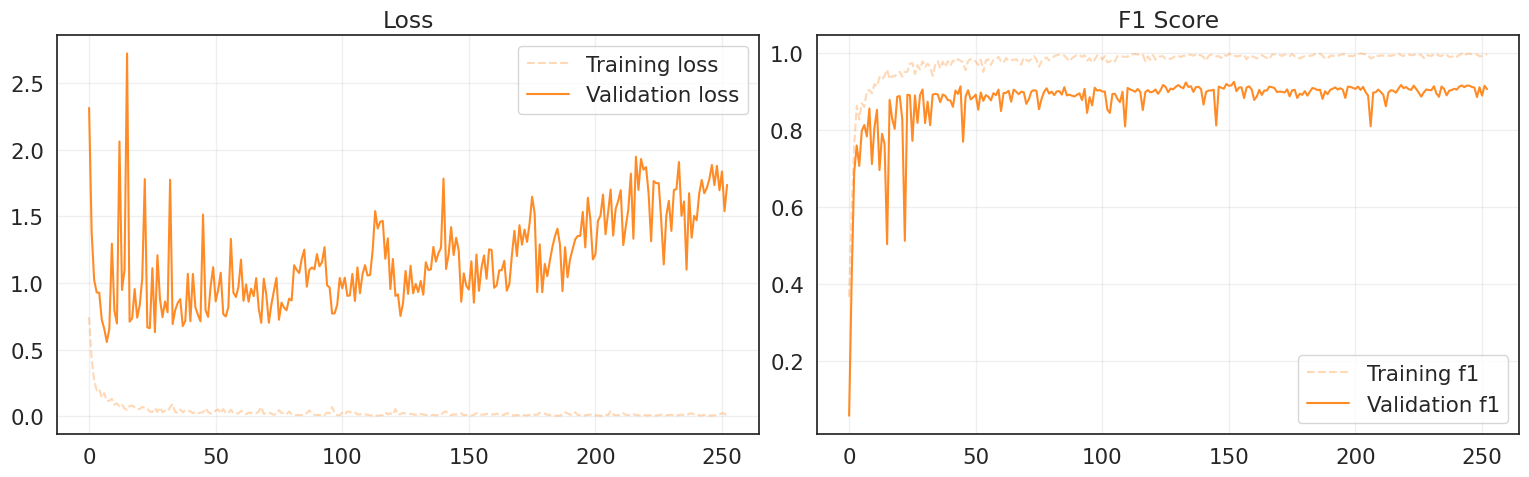

In [ ]:
# @title
# Create a figure with two side-by-side subplots (two columns)
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(18, 5))

# Plot of training and validation loss on the first axis
ax1.plot(training_history['train_loss'], label='Training loss', alpha=0.3, color='#ff7f0e', linestyle='--')
ax1.plot(training_history['val_loss'], label='Validation loss', alpha=0.9, color='#ff7f0e')
ax1.set_title('Loss')
ax1.legend()
ax1.grid(alpha=0.3)

# Plot of training and validation accuracy on the second axis
ax2.plot(training_history['train_f1'], label='Training f1', alpha=0.3, color='#ff7f0e', linestyle='--')
ax2.plot(training_history['val_f1'], label='Validation f1', alpha=0.9, color='#ff7f0e')
ax2.set_title('F1 Score')
ax2.legend()
ax2.grid(alpha=0.3)

# Adjust the layout and display the plot
plt.tight_layout()
plt.subplots_adjust(right=0.85)
plt.show()

Accuracy over the validation set: 0.9248
Precision over the validation set: 0.9281
Recall over the validation set: 0.9248
F1 score over the validation set: 0.9262


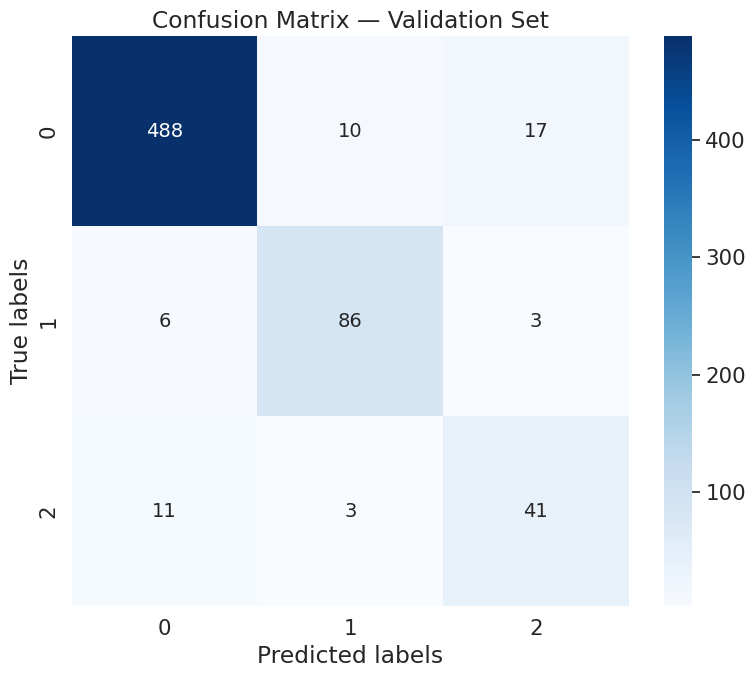

In [ ]:
# @title
# Collect predictions and ground truth labels
val_preds, val_targets = [], []
with torch.no_grad():  # Disable gradient computation for inference
    for xb, yb in val_loader:
        # Move data to device and convert to float32
        xb = xb.to(device).float()

        # Forward pass: get model predictions
        logits = model(xb)
        preds = logits.argmax(dim=1).cpu().numpy()

        # Store batch results
        val_preds.append(preds)
        val_targets.append(yb.numpy())

# Combine all batches into single arrays
val_preds = np.concatenate(val_preds)
val_targets = np.concatenate(val_targets)

# Calculate overall validation metrics
val_acc = accuracy_score(val_targets, val_preds)
val_prec = precision_score(val_targets, val_preds, average='weighted')
val_rec = recall_score(val_targets, val_preds, average='weighted')
val_f1 = f1_score(val_targets, val_preds, average='weighted')
print(f"Accuracy over the validation set: {val_acc:.4f}")
print(f"Precision over the validation set: {val_prec:.4f}")
print(f"Recall over the validation set: {val_rec:.4f}")
print(f"F1 score over the validation set: {val_f1:.4f}")

# Generate confusion matrix for detailed error analysis
cm = confusion_matrix(val_targets, val_preds)

# Create numeric labels for heatmap annotation
labels = np.array([f"{num}" for num in cm.flatten()]).reshape(cm.shape)

# Visualise confusion matrix
plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=labels, fmt='',
            cmap='Blues')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix — Validation Set')
plt.tight_layout()
plt.show()

## Submission


In [ ]:
model = CNN_GRU_Classifier(
    input_size=input_size,
    num_classes=num_classes,
    hidden_size=best_params["hidden_size"],
    num_layers=best_params["num_layers"],
    dropout_rate=best_params["dropout_rate"],
    bidirectional=False,
    use_attention=True
).to(device)

model_path = BASE_PATH+"models/"+"cnn_gru_nobi_optuna_model.pt"

rnn_model.load_state_dict(torch.load(model_path, map_location=device))
rnn_model.to(device)
rnn_model.eval()

CNN_GRU_Classifier(
  (cnn): Sequential(
    (0): Conv1d(34, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (4): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Dropout(p=0.0, inplace=False)
  )
  (gru): GRU(128, 128, num_layers=2, batch_first=True)
  (attention): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=1, bias=False)
  )
  (fc): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.0, inplace=False)
    (3): Linear(in_features=128, out_features=3, bias=True)
  )
)

In [ ]:
# Check loaded model performance
val_loss, val_f1 = validate_one_epoch(rnn_model, val_loader, criterion, device)
print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation F1:   {val_f1:.4f}")

Validation Loss: 0.8522
Validation F1:   0.9262


In [ ]:
num_joints = 29
scale_columns = [f'joint_{i:02d}' for i in range(num_joints+1)]

mins = X_test[scale_columns].min()
maxs = X_test[scale_columns].max()

for column in scale_columns:
    X_test[column] = (X_test[column] - mins[column]) / (maxs[column] - mins[column])

X_test_seq = build_sequences(X_test, best_params["window_size"], best_params["stride"], is_test=True)

X_test_tensor = torch.from_numpy(X_test_seq).float()
test_ds  = TensorDataset(X_test_tensor)

test_loader  = make_loader(test_ds, batch_size= best_params["batch_size"], shuffle=False, drop_last=False)

preds = []
with torch.no_grad():
    for (xb,) in test_loader:
        xb = xb.to(device).float()
        logits = model(xb)
        batch_preds  = torch.argmax(logits, 1)
        preds.extend(batch_preds.cpu().numpy())

preds = np.array(preds)
print("Tot preds:", len(preds))
unique, counts = np.unique(preds, return_counts=True)
print("Distribution:", dict(zip(unique, counts)))

Tot preds: 6620
Distribution: {np.int64(0): np.int64(2157), np.int64(1): np.int64(5), np.int64(2): np.int64(4458)}


In [ ]:
def build_sequences_test(df, window_size, stride):
    """Create temporal windows for the test set from a time-series DataFrame.

    Args:
        df (pd.DataFrame): DataFrame with the 'sample_index' and 'time' columns plus numeric features.
        window_size (int): number of timesteps per window.
        stride (int): step by which the window advances.

    Returns:
        tuple:
            X_seq (np.ndarray): input sequences of shape (n_windows, window_size, n_features)
            seq_indices (np.ndarray): sample_index associated with each window
    """

    feature_cols = [col for col in df.columns if col not in ["sample_index", "time"]]
    X_seq = []
    seq_indices = []

    # Iterate over each subject / sequence
    for sid, group in df.groupby("sample_index"):
        group = group.sort_values("time")
        values = group[feature_cols].values
        n_time = len(values)

        # Create sliding windows
        for start in range(0, n_time - window_size + 1, stride):
            end = start + window_size
            window = values[start:end]
            X_seq.append(window)
            seq_indices.append(sid)

    X_seq = np.stack(X_seq)
    seq_indices = np.array(seq_indices)

    print(f"Created {len(X_seq)} windows from {df['sample_index'].nunique()} samples "
          f"(window={window_size}, stride={stride})")

    return X_seq, seq_indices

X_test_seq, test_indices = build_sequences_test(X_test,
    best_params["window_size"],
    best_params["stride"]
)

X_test_tensor = torch.from_numpy(X_test_seq).float()
test_ds = TensorDataset(X_test_tensor)
test_loader = make_loader(
    test_ds,
    batch_size=best_params["batch_size"],
    shuffle=False,
    drop_last=False
)

preds = []
with torch.no_grad():
    for (xb,) in test_loader:
        xb = xb.to(device).float()
        logits = model(xb)
        batch_preds  = torch.argmax(logits, 1)
        preds.extend(batch_preds.cpu().numpy())

window_df = pd.DataFrame({
    "sample_index": test_indices,
    "pred": preds
})

final_preds = (
    window_df.groupby("sample_index")["pred"]
    .agg(lambda x: np.bincount(x).argmax())   # moda
    .reindex(sorted(X_test["sample_index"].unique()))
)

preds = np.array(final_preds)
print("Tot preds:", len(preds))
unique, counts = np.unique(final_preds, return_counts=True)
print("Distribution:", dict(zip(unique, counts)))


 Created 3972 windows from 1324 samples (window=100, stride=25)


[Note added when preparing this repository] This cell ended with RuntimeError during the original Colab run. The traceback was removed for readability; the surrounding cells show the results that were kept.


In [ ]:
label_map   = {0: "no_pain", 1: "low_pain", 2: "high_pain"}
pred_labels = [label_map[int(p)] for p in preds]

In [ ]:
import datetime as dt

sample_submission = pd.read_csv("../Dataset/sample_submission.csv")

submission = sample_submission.copy()
submission["label"] = pred_labels

ts = dt.datetime.now().strftime("%Y%m%d_%H%M%S")
submission.to_csv("submission.csv", index=False)
submission.to_csv(f"submission_{ts}.csv", index=False)

display(submission.head())

,sample_index,label
0,0,no_pain
1,1,no_pain
2,2,no_pain
3,3,no_pain
4,4,no_pain
